<h2>Importing necessary libraries</h2>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

<h2>Loading Dataset</h2>

In [2]:
df = pd.read_csv("Telco_Customer_Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<h2>Data Cleaning</h2>

In [4]:
df.shape

(7043, 21)

In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated(subset=['customerID']).sum()

np.int64(0)

<h2>Exploratory Data Analysis</h2>

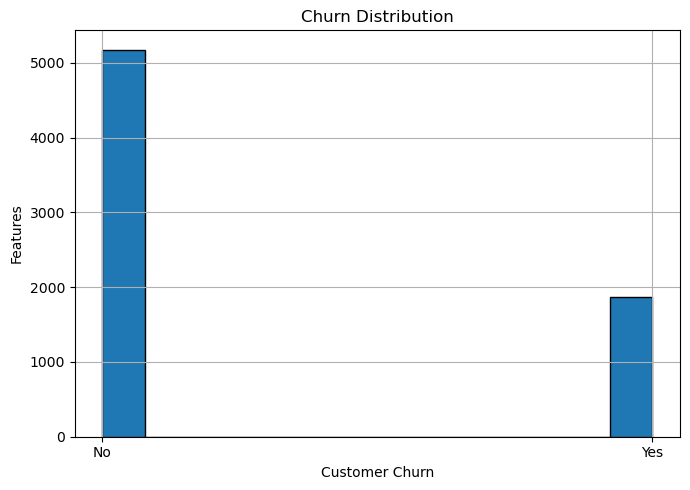

In [9]:
#Churn Distribution using histogram
plt.figure(figsize=(7,5))
plt.hist(df['Churn'],bins=int(np.log2(len(df['Churn']))+1),edgecolor='black')
plt.xlabel('Customer Churn')
plt.ylabel('Features')
plt.title('Churn Distribution')
plt.grid(visible=True)
plt.tight_layout()
plt.show()

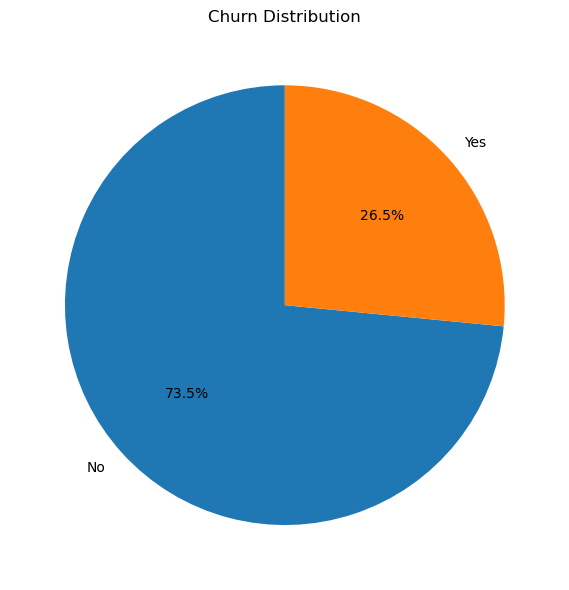

In [10]:
#Churn Distribution using piechart
plt.close('all')

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)

plt.title('Churn Distribution')
plt.tight_layout()
plt.show()

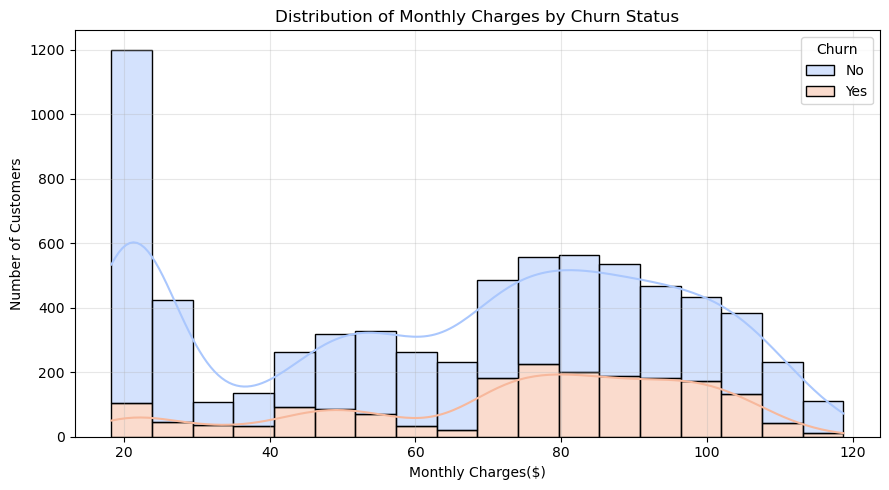

In [11]:
#Distribution of Monthly Charges by Churn Status
plt.close('all')
plt.figure(figsize=(9,5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='coolwarm', multiple='stack')
plt.xlabel('Monthly Charges($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges by Churn Status')
plt.grid(visible=True, alpha=0.3)
plt.tight_layout()
plt.show()

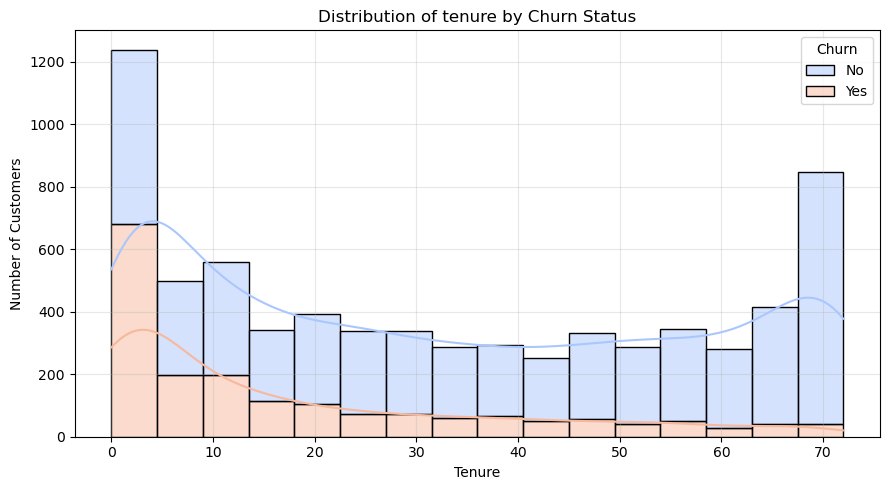

In [12]:
#Distribution of tenure by Churn Status
plt.close('all')
plt.figure(figsize=(9,5))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette='coolwarm', multiple='stack')
plt.xlabel('Tenure')
plt.ylabel('Number of Customers')
plt.title('Distribution of tenure by Churn Status')
plt.grid(visible=True, alpha=0.3)
plt.tight_layout()
plt.show()

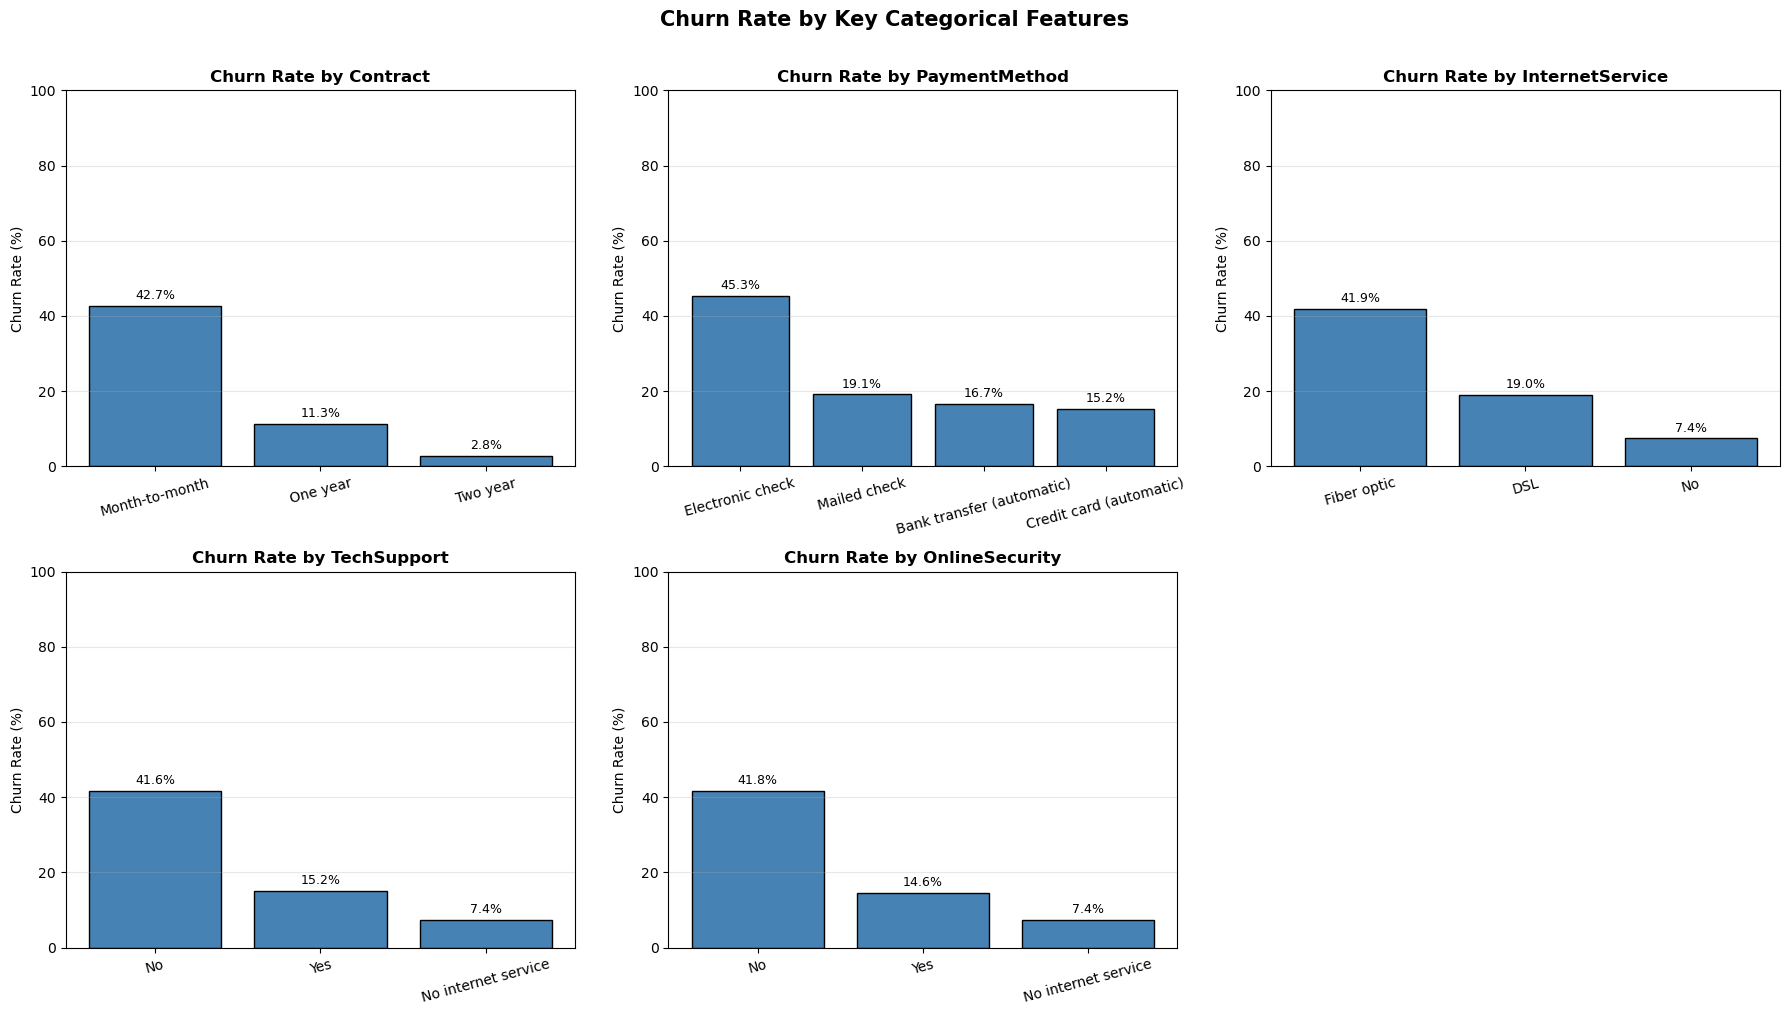

In [13]:
# --- Bivariate EDA: Churn by Key Categorical Features ---
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

cat_features = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']

plt.close('all')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    
    bars = axes[i].bar(churn_rate.index, churn_rate.values * 100, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

<h2>Feature Engineering</h2>

In [15]:
# Convert TotalCharges to numeric (handles blank strings for new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 1. Charge-to-tenure ratio: how much a customer pays relative to loyalty
#    High ratio = new customer paying a lot → higher churn risk
df['ChargePerTenureMonth'] = df['MonthlyCharges'] / (df['tenure'] + 1)  # +1 avoids division by zero

# 2. Tenure bucket: loyalty stage
df['TenureBucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, np.inf],
    labels=['New', 'Growing', 'Established', 'Loyal'],
    right=True
)

# 3. Service count: number of add-on services subscribed
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

# 4. High value flag: customers paying above median monthly charges
median_charge = df['MonthlyCharges'].median()
df['IsHighValue'] = (df['MonthlyCharges'] > median_charge).astype(int)

print("New features added:")
print(df[['ChargePerTenureMonth', 'TenureBucket', 'ServiceCount', 'IsHighValue']].head(10))
print(f"\nTenureBucket distribution:\n{df['TenureBucket'].value_counts()}")
print(f"\nAvg ServiceCount by Churn:\n{df.groupby('Churn')['ServiceCount'].mean()}")

New features added:
   ChargePerTenureMonth TenureBucket  ServiceCount  IsHighValue
0             14.925000          New             1            0
1              1.627143  Established             2            0
2             17.950000          New             2            0
3              0.919565  Established             3            0
4             23.566667          New             0            1
5             11.072222          New             3            1
6              3.873913      Growing             2            1
7              2.704545          New             1            0
8              3.613793  Established             4            1
9              0.891270        Loyal             2            0

TenureBucket distribution:
TenureBucket
Loyal          2239
New            2175
Established    1594
Growing        1024
Name: count, dtype: int64

Avg ServiceCount by Churn:
Churn
0    2.135292
1    1.768325
Name: ServiceCount, dtype: float64


In [16]:
#Dropping column customer id
df = df.drop('customerID',axis='columns')

In [17]:
df['Churn'].dtype

dtype('int64')

<h2>Data Preprocessing</h2>

In [18]:
#Outlier removal using z_score function
def remove_outliers_zscore(df, threshold=3):
    df_clean = df.copy()
    
    # Iterate through all columns
    for col in df_clean.columns:
        # Check if the column is numeric
        if df_clean[col].dtype in ['int64', 'float64']:
            col_mean = df_clean[col].mean()
            col_std = df_clean[col].std()
            
            # Avoid division by zero if std deviation is 0
            if col_std == 0:
                continue
                
            z_scores = np.abs((df_clean[col] - col_mean) / col_std)
            
            # Keep rows where the z-score is less than the threshold
            outliers_condition = z_scores < threshold
            outliers_removed = len(df_clean) - outliers_condition.sum()
            
            df_clean = df_clean[outliers_condition]
            
            print(f"Processing Column: {col}")
            print(f"Total outliers detected and removed: {outliers_removed}")
            print(f"Number of rows remaining: {len(df_clean)}")
            print("-" * 40)
            
    return df_clean

In [19]:
#Create a function build_pipeline to handle numeric and categorical features
def build_pipeline(num_att, cat_att):
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # ✅ Added imputer
        ('scaler', StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),  # ✅ Added imputer
        ('oe', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])

    final_pipeline = ColumnTransformer([
        ('num', num_pipeline, num_att),
        ('cat', cat_pipeline, cat_att)
    ])

    return final_pipeline

In [20]:
#Splitting whole data into train and test set
X = df.drop('Churn',axis='columns')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

train_df = X_train.copy()
train_df['Churn'] = y_train.values

train_df_clean = remove_outliers_zscore(train_df)

X_train = train_df_clean.drop('Churn', axis='columns')
y_train = train_df_clean['Churn']

Processing Column: SeniorCitizen
Total outliers detected and removed: 0
Number of rows remaining: 5634
----------------------------------------
Processing Column: tenure
Total outliers detected and removed: 0
Number of rows remaining: 5634
----------------------------------------
Processing Column: MonthlyCharges
Total outliers detected and removed: 0
Number of rows remaining: 5634
----------------------------------------
Processing Column: TotalCharges
Total outliers detected and removed: 8
Number of rows remaining: 5626
----------------------------------------
Processing Column: ChargePerTenureMonth
Total outliers detected and removed: 205
Number of rows remaining: 5421
----------------------------------------
Processing Column: ServiceCount
Total outliers detected and removed: 0
Number of rows remaining: 5421
----------------------------------------
Processing Column: IsHighValue
Total outliers detected and removed: 0
Number of rows remaining: 5421
----------------------------------

In [21]:
y_train.dtype

dtype('int64')

In [22]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

num_att = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_att = X_train.select_dtypes(include=['object','category']).columns.tolist()
all_cols = num_att + cat_att

#Calling fuction build pipeline to preprocess features on X_train
preprocessor = build_pipeline(num_att, cat_att)
preprocessor.set_output(transform='default')

X_scaled = preprocessor.fit_transform(X_train)
X_scaled = pd.DataFrame(X_scaled.astype(np.float64), columns=all_cols)

X_test_scaled = preprocessor.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled.astype(np.float64), columns=all_cols)

In [23]:
print(f"No of columns and row in X_train: {X_scaled.shape}")
print(f"No of columns and row in X_test: {X_test_scaled.shape}")

No of columns and row in X_train: (5421, 23)
No of columns and row in X_test: (1409, 23)


In [24]:
X_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargePerTenureMonth,ServiceCount,IsHighValue,gender,Partner,Dependents,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TenureBucket
0,-0.436927,0.052773,-0.499698,-0.300432,-0.532436,0.481981,-0.987352,1.0,0.0,0.0,...,0.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,2.0,0.0
1,-0.436927,-0.772869,0.348552,-0.541742,0.043193,-0.591045,1.012810,1.0,1.0,1.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0
2,-0.436927,-0.855433,-0.782994,-0.787920,-0.267767,0.481981,-0.987352,1.0,1.0,1.0,...,2.0,2.0,0.0,2.0,0.0,0.0,2.0,0.0,3.0,1.0
3,-0.436927,-0.318766,0.296151,-0.210923,-0.297907,1.018493,1.012810,0.0,1.0,0.0,...,0.0,2.0,2.0,0.0,2.0,2.0,2.0,1.0,1.0,0.0
4,-0.436927,-1.350818,-0.651990,-1.027343,3.084981,-1.127557,-0.987352,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0


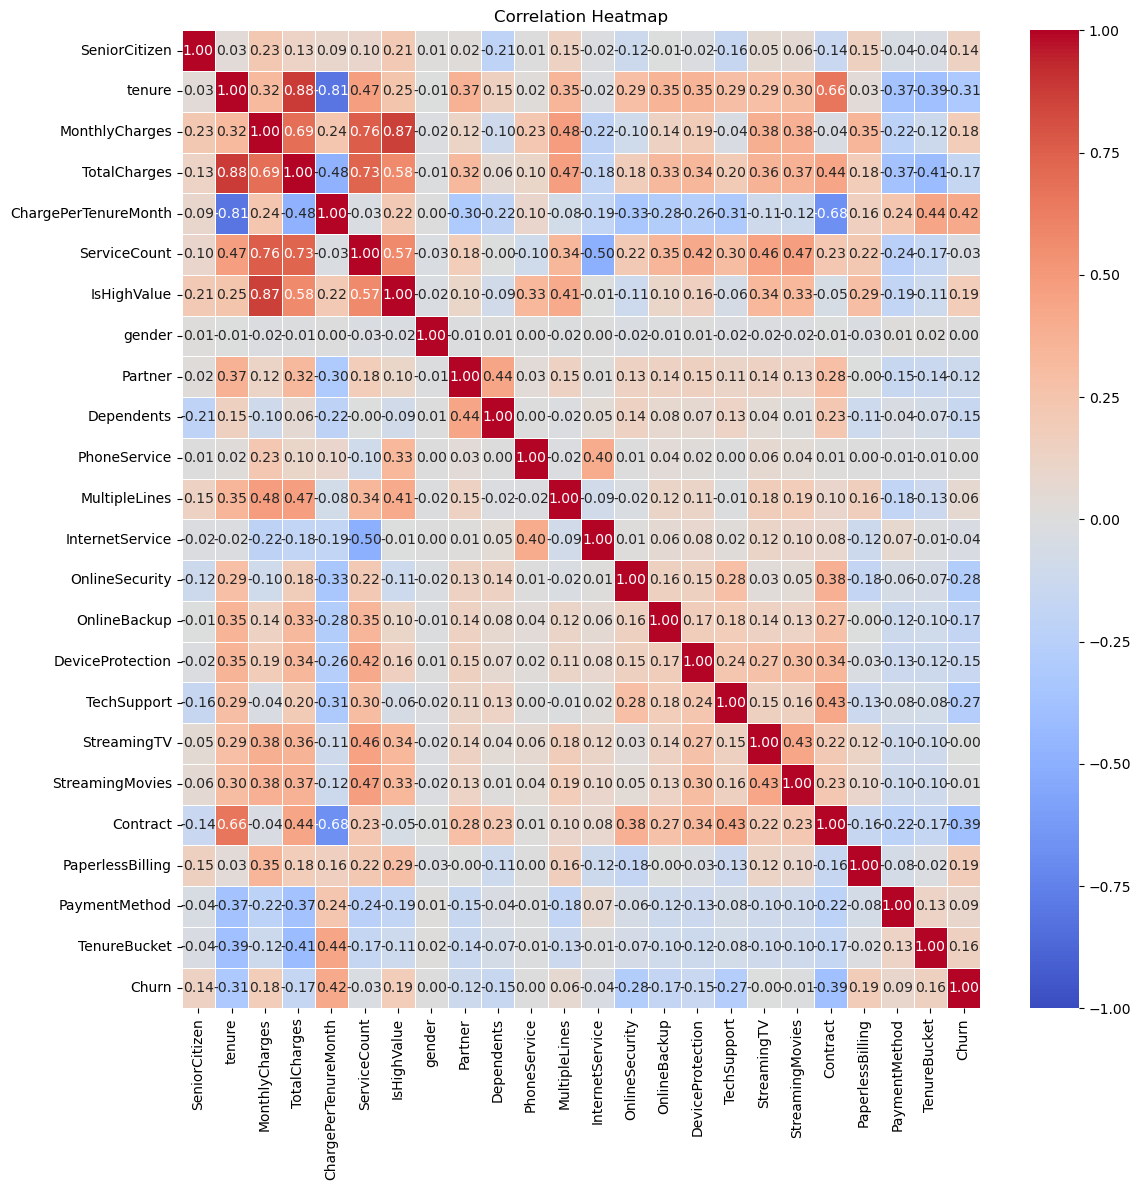

In [25]:
#Correlation Heatmap
plt.close('all')
plt.figure(figsize=(12,12))

numeric_df = pd.concat([X_scaled.select_dtypes(include=['int64','float64']),y_train],axis=1)
corr_matrix = numeric_df.corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [26]:
#Creating function to drop columns which have very low correlation with target feature
def get_low_corr_columns(df, y_series, target_col, threshold=0.02):
    columns_to_drop = []
    
    # Loop through columns, making sure we don't calculate correlation of target with itself
    df_numeric = df.reset_index(drop=True).apply(pd.to_numeric, errors='coerce')
    y_reset = pd.Series(y_series.values)
    
    for col in df_numeric.columns:
        if col == target_col:
            continue
            
        try:
            # Calculate absolute Spearman correlation
            col_corr = df_numeric[col].corr(y_reset, method='spearman')
            
            # Use absolute value to capture both weak positive and weak negative relationships
            if abs(col_corr) < threshold or pd.isna(col_corr):
                print(f"'{col}' marked for deletion (Weak correlation: {col_corr:.4f})")
                columns_to_drop.append(col)
            else:
                pass
        except Exception as e:
            # Skips non-numeric columns (like text/categorical strings) that can't compute correlation
            print(f"Skipping non-numeric column: '{col}'")
            
    return columns_to_drop

# Force convert to numeric if needed
X_scaled = X_scaled.reset_index(drop=True).apply(pd.to_numeric, errors='coerce')
X_test_scaled = X_test_scaled.reset_index(drop=True).apply(pd.to_numeric, errors='coerce')
y_train = y_train.reset_index(drop=True)

# 1. Identify which columns to drop
cols_to_remove = get_low_corr_columns(X_scaled, y_train, target_col='Churn', threshold=0.02)

# 2. Drop them safely all at once
X_scaled_final = X_scaled.drop(columns=cols_to_remove)
X_test_final = X_test_scaled.drop(columns=cols_to_remove)

'gender' marked for deletion (Weak correlation: 0.0002)
'PhoneService' marked for deletion (Weak correlation: 0.0015)
'StreamingTV' marked for deletion (Weak correlation: -0.0047)
'StreamingMovies' marked for deletion (Weak correlation: -0.0111)


In [27]:
X_scaled_final.shape

(5421, 19)

In [28]:
X_scaled_final.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargePerTenureMonth,ServiceCount,IsHighValue,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,TenureBucket
0,-0.436927,0.052773,-0.499698,-0.300432,-0.532436,0.481981,-0.987352,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0
1,-0.436927,-0.772869,0.348552,-0.541742,0.043193,-0.591045,1.012810,1.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0
2,-0.436927,-0.855433,-0.782994,-0.787920,-0.267767,0.481981,-0.987352,1.0,1.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,0.0,3.0,1.0
3,-0.436927,-0.318766,0.296151,-0.210923,-0.297907,1.018493,1.012810,1.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,1.0,1.0,0.0
4,-0.436927,-1.350818,-0.651990,-1.027343,3.084981,-1.127557,-0.987352,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0


In [29]:
X_scaled_final.isnull().sum()

SeniorCitizen           0
tenure                  0
MonthlyCharges          0
TotalCharges            0
ChargePerTenureMonth    0
ServiceCount            0
IsHighValue             0
Partner                 0
Dependents              0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
Contract                0
PaperlessBilling        0
PaymentMethod           0
TenureBucket            0
dtype: int64

<h2>Model Building and Training</h2>

In [30]:
model_param = {
    'Logistic Regression':{
        'model' : LogisticRegression(),
        'param' :{
            'C' : [1,5,10]
         }
    },

    'Decision Tree':{
        'model' : DecisionTreeClassifier(random_state=42),
        'param':{
            'max_depth' : [1,5,10]
        } 
     },

     'Random Forest':{
         'model' : RandomForestClassifier(random_state=42),
         'param':{
            'n_estimators'     : [100, 175, 250],
            'max_depth'        : [10, 20, None],
            'min_samples_split': [2, 20, 50],
         }
     }
}

In [31]:
#Using grid search cv to find best model
scores = []
scoring = ['accuracy','precision','recall','f1']

for model,mp in model_param.items():
    for matrix in scoring:
        gs = GridSearchCV(mp['model'],mp['param'],cv=5, scoring = matrix, n_jobs = -1, verbose = 1)
        gs.fit(X_scaled_final, y_train)
        scores.append({
            'best_model' : model,     
            'scoring' : matrix,
            'best_param' : gs.best_params_,
            'best_score' : gs.best_score_,
        })

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Fitting 5 folds for each of 27 candidates, totalling 135 fits


In [32]:
pd.set_option('display.max_colwidth',None)
result = pd.DataFrame(scores, columns=['best_model','scoring','best_param','best_score'])
result

,best_model,scoring,best_param,best_score
0,Logistic Regression,accuracy,{'C': 5},0.804462
1,Logistic Regression,precision,{'C': 5},0.638958
2,Logistic Regression,recall,{'C': 5},0.460709
3,Logistic Regression,f1,{'C': 5},0.534939
4,Decision Tree,accuracy,{'max_depth': 5},0.779192
5,Decision Tree,precision,{'max_depth': 5},0.571464
6,Decision Tree,recall,{'max_depth': 10},0.409362
7,Decision Tree,f1,{'max_depth': 5},0.450788
8,Random Forest,accuracy,"{'max_depth': 20, 'min_samples_split': 50, 'n_estimators': 250}",0.796530
9,Random Forest,precision,"{'max_depth': 20, 'min_samples_split': 50, 'n_estimators': 250}",0.630454


In [33]:
# 1. Instantiate the final model with your optimal hyperparameters
final_model = RandomForestClassifier(
    max_depth=10, 
    min_samples_split=50, 
    n_estimators=100, 
    random_state=42
)

# 2. Fit the model to your complete cleaned training data
final_model.fit(X_scaled_final, y_train)

# 3. Generate predictions on your unseen test data cleanly
y_pred = final_model.predict(X_test_final)

    
# Calculate and print metrics using sklearn.metrics functions
print(f"Accuracy of the model = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision of the model = {precision_score(y_test, y_pred):.4f}")
print(f"Recall of the model = {recall_score(y_test, y_pred):.4f}")
print(f"F1 of the model = {f1_score(y_test, y_pred):.4f}")

# Print a quick confirmation to verify it works!
print("Success! Generated predictions for", len(y_pred), "customers.")
print("First 10 predictions:", y_pred[:10])

Accuracy of the model = 0.8013
Precision of the model = 0.6808
Recall of the model = 0.4733
F1 of the model = 0.5584
Success! Generated predictions for 1409 customers.
First 10 predictions: [0 1 0 0 0 1 0 0 0 0]


In [34]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[952,  83],
       [197, 177]])

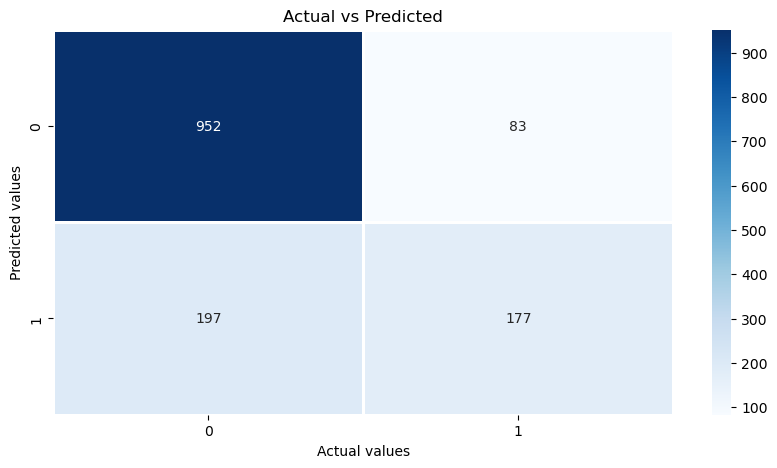

In [35]:
#Confusion Matrix Heatmap
plt.close('all')
plt.figure(figsize=(10,5))

sns.heatmap(cm, annot=True, cmap='Blues', linewidth=2, linecolor='white', fmt='d')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted')
plt.show()

In [36]:
#Saving model and preprocessed data
import joblib 
joblib.dump(final_model,'random_forest_churn_prediction_model.pkl')
joblib.dump(preprocessor,'preprocessor.pkl')

['preprocessor.pkl']